# 03 订单超时风险模型：决策时点与跨期验证

本 Notebook 比较两个业务时点：订单进入配送系统时的早期预警，以及骑手接单时的更新预警。目标是排序风险，不是用模型替代运力策略的因果评估。

## 管理摘要

- 测试集为 2022-10-23 至 2022-10-24，共 **111,835 单**，超时率 **13.79%**；训练数据严格早于测试日期。
- 进入配送时模型：测试 PR-AUC **0.267**，Top 10% 风险订单覆盖 **20.96%** 的实际超时，Lift **2.10**。
- 接单时模型：测试 PR-AUC **0.314**，Top 10% 覆盖 **24.84%**，Lift **2.48**；即最高风险 10% 订单的超时率约为总体的 2.48 倍。
- 仅按配送距离排序的 PR-AUC 为 **0.185**、Lift 为 **1.53**，说明模型增加了时段、商圈、承诺时长和派单摩擦信号。
- 骑手接单时模型依赖度较高的特征包括承诺时长、配送距离、成功派单等待、下单至进入配送时间、匿名商圈和接单位置至商家距离。
- 骑手接单时模型识别能力更强，但对应更晚的运营处置时点；其离线表现不能外推为订单推送时的早期识别能力。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_OUT = PROJECT_ROOT / "outputs" / "model"
metrics = pd.read_csv(MODEL_OUT / "model_metrics.csv")
predictions = pd.read_parquet(MODEL_OUT / "test_predictions.parquet")
importance = pd.read_csv(MODEL_OUT / "acceptance_model_permutation_importance.csv")

metrics

,split,model,rows,late_orders,late_rate,roc_auc,pr_auc,brier,recall_at_top_10pct,precision_at_top_10pct,lift_at_top_10pct
0,validation_20221022,push_time_model,59531,8176,0.1373,0.6678,0.2535,0.1124,0.1964,0.2697,1.9640
1,validation_20221022,acceptance_time_model,59531,8176,0.1373,0.7040,0.3045,0.1090,0.2435,0.3344,2.4348
2,test_20221023_20221024,push_time_model,111835,15417,0.1379,0.6777,0.2672,0.1119,0.2096,0.2890,2.0963
3,test_20221023_20221024,acceptance_time_model,111835,15417,0.1379,0.7097,0.3142,0.1087,0.2484,0.3425,2.4842
4,test_20221023_20221024,distance_only_ranking,111835,15417,0.1379,0.6172,0.1846,NaN,0.1527,0.2105,1.5268


## 1. 跨期验证方案与预测时点

| 阶段 | 日期 | 作用 |
|---|---|---|
| 候选训练 | 10-17 至 10-21 | 比较两个预测时点 |
| 验证 | 10-22 | 验证候选表现 |
| 最终训练 | 10-17 至 10-22 | 训练交付模型 |
| 跨期测试 | 10-23 至 10-24 | 独立效果评估 |

进入配送时模型只能使用当时已知的信息；接单时模型才允许使用已经发生的派单等待、拒单次数和接单位置。取餐、送达、波次最终订单数均禁止进入特征。

## 2. 验证与测试表现

In [2]:
metric_view = metrics[
    [
        "split", "model", "rows", "late_rate", "roc_auc", "pr_auc", "brier",
        "recall_at_top_10pct", "precision_at_top_10pct", "lift_at_top_10pct",
    ]
].copy()
metric_view

,split,model,rows,late_rate,roc_auc,pr_auc,brier,recall_at_top_10pct,precision_at_top_10pct,lift_at_top_10pct
0,validation_20221022,push_time_model,59531,0.1373,0.6678,0.2535,0.1124,0.1964,0.2697,1.9640
1,validation_20221022,acceptance_time_model,59531,0.1373,0.7040,0.3045,0.1090,0.2435,0.3344,2.4348
2,test_20221023_20221024,push_time_model,111835,0.1379,0.6777,0.2672,0.1119,0.2096,0.2890,2.0963
3,test_20221023_20221024,acceptance_time_model,111835,0.1379,0.7097,0.3142,0.1087,0.2484,0.3425,2.4842
4,test_20221023_20221024,distance_only_ranking,111835,0.1379,0.6172,0.1846,NaN,0.1527,0.2105,1.5268


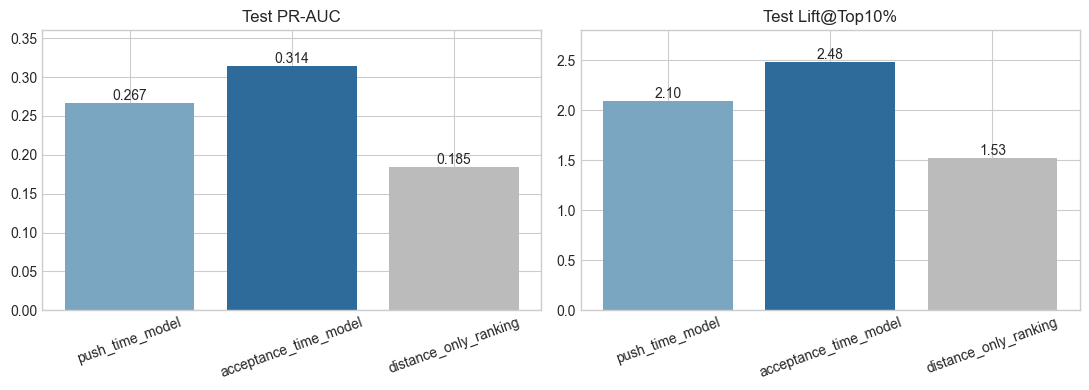

In [3]:
test_metrics = metrics.loc[metrics["split"].eq("test_20221023_20221024")].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(test_metrics["model"], test_metrics["pr_auc"], color=["#7AA6C2", "#2F6B9A", "#BBBBBB"])
axes[0].set_title("Test PR-AUC")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0, 0.36)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.3f")

axes[1].bar(
    test_metrics["model"], test_metrics["lift_at_top_10pct"],
    color=["#7AA6C2", "#2F6B9A", "#BBBBBB"]
)
axes[1].set_title("Test Lift@Top10%")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 2.8)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.2f")
plt.tight_layout()
plt.show()

骑手接单时模型在验证日和测试日均优于订单推送时模型，表明已发生的派单摩擦提供了增量预测信息。但两个模型对应不同运营决策：事前资源准备与早期预警应使用订单推送时模型，接单后异常处置可使用更新模型。模型选择应服从决策时点，而不能仅依据离线指标高低。

## 3. 风险分层与校准检查

In [4]:
score_col = "acceptance_time_model_risk"
predictions["risk_decile"] = pd.qcut(
    predictions[score_col].rank(method="first"), 10,
    labels=[f"D{i}" for i in range(1, 11)]
)
decile = (
    predictions.groupby("risk_decile", observed=True)
    .agg(
        orders=("order_id", "size"),
        avg_predicted_risk=(score_col, "mean"),
        actual_late_rate=("is_late", "mean"),
        late_orders=("is_late", "sum"),
    )
    .reset_index()
)
decile

,risk_decile,orders,avg_predicted_risk,actual_late_rate,late_orders
0,D1,11184,0.0167,0.0238,266
1,D2,11183,0.0365,0.0478,534
2,D3,11184,0.0571,0.0633,708
3,D4,11183,0.0792,0.0911,1019
4,D5,11184,0.1014,0.1133,1267
5,D6,11183,0.1235,0.1405,1571
6,D7,11183,0.1469,0.1554,1738
7,D8,11184,0.1736,0.1832,2049
8,D9,11183,0.2106,0.2177,2435
9,D10,11184,0.3453,0.3425,3830


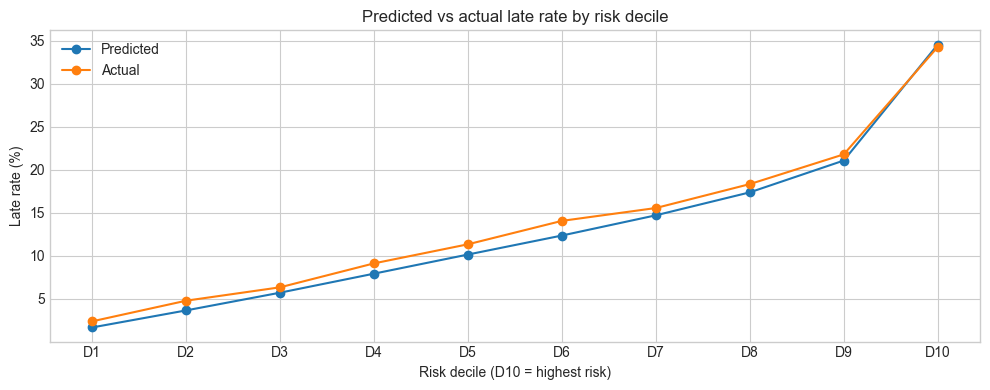

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(decile))
ax.plot(x, decile["avg_predicted_risk"] * 100, marker="o", label="Predicted")
ax.plot(x, decile["actual_late_rate"] * 100, marker="o", label="Actual")
ax.set_xticks(x, decile["risk_decile"])
ax.set_xlabel("Risk decile (D10 = highest risk)")
ax.set_ylabel("Late rate (%)")
ax.set_title("Predicted vs actual late rate by risk decile")
ax.legend()
plt.tight_layout()
plt.show()

风险十分位应呈单调梯度；预测概率与实际发生率的差距则提示校准程度。项目以排序为主要用途，若上线用于资源预算，仍需更长时间窗口上的概率校准和稳定性监控。

## 4. 两个测试日的稳定性

In [6]:
daily_rows = []
for dt, group in predictions.groupby("dt"):
    y = group["is_late"].astype(int)
    for model_name, score in [
        ("push_time_model", "push_time_model_risk"),
        ("acceptance_time_model", "acceptance_time_model_risk"),
    ]:
        daily_rows.append({
            "dt": dt,
            "model": model_name,
            "orders": len(group),
            "late_rate": y.mean(),
            "roc_auc": roc_auc_score(y, group[score]),
            "pr_auc": average_precision_score(y, group[score]),
        })
daily_stability = pd.DataFrame(daily_rows)
daily_stability

,dt,model,orders,late_rate,roc_auc,pr_auc
0,20221023,push_time_model,59898,0.1491,0.6728,0.2779
1,20221023,acceptance_time_model,59898,0.1491,0.7048,0.3252
2,20221024,push_time_model,51937,0.1248,0.6820,0.2525
3,20221024,acceptance_time_model,51937,0.1248,0.7140,0.2994


仅两个测试日不足以证明长期稳定。这里的目的，是检查模型没有在第二天立即失效；正式应用应按周监控 PR-AUC、Top-K 覆盖、校准和商圈分层表现。

## 5. 特征重要性

In [7]:
importance.head(12)

,feature,pr_auc_importance_mean,pr_auc_importance_std
0,promise_minutes,0.0697,0.0012
1,merchant_customer_distance_km,0.0604,0.0016
2,accepted_dispatch_wait_minutes,0.0594,0.0008
3,order_to_push_minutes,0.0581,0.0014
4,da_id,0.0354,0.0000
5,courier_merchant_distance_at_accept_km,0.0264,0.0001
6,push_hour,0.0255,0.0016
7,accepted_dispatch_to_grab_minutes,0.0142,0.0017
8,first_dispatch_wait_minutes,0.0026,0.0003
9,push_weekday,0.0010,0.0002


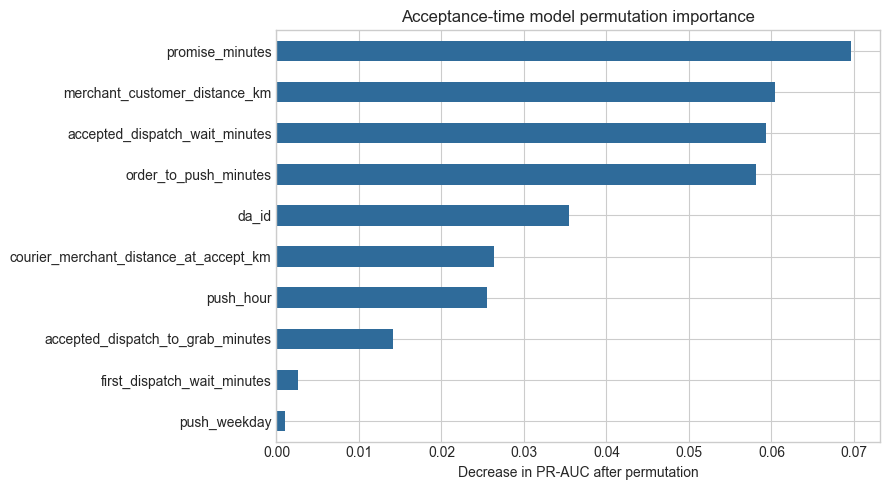

In [8]:
top_importance = importance.head(10).sort_values("pr_auc_importance_mean")
ax = top_importance.plot(
    x="feature", y="pr_auc_importance_mean", kind="barh", legend=False,
    figsize=(9, 5), color="#2F6B9A"
)
ax.set_title("Acceptance-time model permutation importance")
ax.set_xlabel("Decrease in PR-AUC after permutation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Permutation importance 表示模型排序依赖哪些字段，不表示因果效应。尤其承诺时长可能是平台已经根据订单难度做出的预测；它重要不等于延长承诺一定能改善真实履约。

## 6. 运营应用与治理要求

- **排班前/订单进入配送时：** 用早期模型汇总商圈 × 30 分钟风险订单规模，作为运力优先级的一个输入；
- **骑手接单后：** 用更新模型将 Top 10% 风险订单加入运营关注队列；
- **护栏：** 不能把模型风险直接当作可避免超时，不能把 Top 10% 之外视为安全，也不能把测试结果写成线上提升。

下一步将风险评分接入供需决策：使用官方午高峰候选骑手快照构造空间供需压力指标，并开展包含预算上限与配置集中度约束的离线策略回放。

## Sources

- `outputs/model/model_metrics.csv`
- `outputs/model/test_predictions.parquet`
- `outputs/model/acceptance_model_permutation_importance.csv`
- `docs/06_model_design.md`
- `scripts/train_late_risk_model.py`